# Analyse Exploratoire - Projet Seattle
### Prédiction des émissions de la consommation d'énergie des bâtiments

**Objectif** : Aider la ville de Seattle à atteindre son objectif de neutralité carbone en 2050 en prédisant les émissions de CO2 ou la consommation d'énergie des bâtiments non résidentiels à partir de leurs caractéristiques structurelles.

Données : Relevés de consommation énergétique des bâtiments de Seattle en 2016

Étapes de cette analyse :

    Configuration et chargement des données
    Vue d'ensemble du dataset
    Exploration des variables
    Nettoyage des données
    Choix de la variable cible
    Nettoyage finale du Dataset
    Conclusions et prochaines étapes


## 1/Configuration et imports

In [1]:
pip install pandas numpy matplotlib scikit-learn category_encoders

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder

In [3]:
df = pd.read_csv('seattle.csv')
print("Dataset chargé avec succès")
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dataset chargé avec succès
Dimensions : 3376 lignes × 46 colonnes


## 2/ Vue d'ensemble du dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [5]:
# Analyse des types de données
type_counts = df.dtypes.value_counts()

print("="*80)
print("📊 RÉPARTITION DES TYPES DE DONNÉES")
print("="*80)
for dtype, count in type_counts.items():
    print(f"  {dtype}: {count} colonnes")
print("="*80)

# Séparer par catégorie
numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
categorielles = df.select_dtypes(include=['object']).columns.tolist()
booleens = df.select_dtypes(include=['bool']).columns.tolist()

print(f"\n✅ Variables numériques : {len(numeriques)}")
print(f"✅ Variables catégorielles : {len(categorielles)}")
print(f"✅ Variables booléennes : {len(booleens)}")

📊 RÉPARTITION DES TYPES DE DONNÉES
  float64: 22 colonnes
  object: 15 colonnes
  int64: 8 colonnes
  bool: 1 colonnes

✅ Variables numériques : 30
✅ Variables catégorielles : 15
✅ Variables booléennes : 1


In [6]:
#afficher les 1eres lignes
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


**Analyse**  
Parmis les 46 variables, 12 ne sont pas utile car :
- 2 variables ne varient pas : DataYear : 2016, et City : Seattle
- 4 variables apportent de mêmes informations concernant la localisation (address, city, state, Zipcode).  
Je garde d'autres variables plus pertinentes sur le sujet : **CouncilDistrictCode** et **Neighborhood**.
- 2 variables sont constitués arbitrairement : Property Name (nom des batiments), TaxParcelIdentificationNumber
- 2 variables font doublons car déjà calculé en kBtu : Electricity(kWh), NaturalGas(therms)
- 1 variable completement vide : Comments

In [7]:
colonnes_a_supprimer =[
    'OSEBuildingID',
    'PropertyName',
    'Address',
    'City',
    'State',
    'ZipCode',
    'TaxParcelIdentificationNumber',
    'Electricity(kWh)',
    'NaturalGas(therms)',
    'Comments', 
]

df = df.drop(columns=colonnes_a_supprimer)

In [8]:
print(f"Après suppression des colonnes inutiles. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après suppression des colonnes inutiles. Le nouveau dataset est composé de 3376 lignes et de 36 colonnes


 ## 3/ Nettoyage des données

### A/ Analyse de la colonne Outlier du Dataset

Distribution des **Outliers avec une valeur non-nulle** pour les colonnes suivantes :
 - BuildingType (Type de bâtiment)
 - PrimaryPropertyType (Utilisation principale)
 - PropertyGFABuilding(s) (Surface des bâtiments)
 - SiteEnergyUse(kBtu) (énergie consommé)
 - TotalGHGEmissions (Emission CO2) 

In [9]:
outliers_complets = df[df['Outlier'].notna()]

print(f"Nombre d'outliers trouvés : {len(outliers_complets)}")

colonnes_importantes = ['BuildingType', 
                        'PrimaryPropertyType', 'PropertyGFABuilding(s)', 
                        'SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'Outlier']

# Afficher tous les 32 outliers
display(outliers_complets[colonnes_importantes])

Nombre d'outliers trouvés : 32


,BuildingType,PrimaryPropertyType,PropertyGFABuilding(s),SiteEnergyUse(kBtu),TotalGHGEmissions,Outlier
226,NonResidential,Large Office,146922,4.139950e+07,362.66,High outlier
384,NonResidential,Retail Store,69492,3.189628e+05,2.22,Low outlier
448,NonResidential,Large Office,154159,1.119592e+07,29.43,Low outlier
517,NonResidential,Large Office,87051,2.713719e+07,189.18,High outlier
720,Multifamily HR (10+),High-Rise Multifamily,167941,2.407904e+06,29.25,Low outlier
834,Multifamily LR (1-4),Low-Rise Multifamily,31702,2.559712e+05,1.78,Low outlier
839,SPS-District K-12,K-12 School,35805,4.314717e+05,11.54,Low outlier
962,Multifamily LR (1-4),Low-Rise Multifamily,70207,7.024814e+05,4.90,Low outlier
1045,NonResidential,Retail Store,39900,1.454688e+05,5.46,Low outlier
1229,NonResidential,Small- and Mid-Sized Office,57720,2.410550e+04,0.17,Low outlier


## **Suppression des individus qui contenus dans la colonne Outlier, puis suppression la colonne Outlier**

In [10]:
index_outlier = df[df['Outlier'].notna()].index
df.drop(index = index_outlier, inplace=True)

df.drop(columns=['Outlier'], inplace=True)

In [11]:
print(f"Après la suppression des Outlier. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après la suppression des Outlier. Le nouveau dataset est composé de 3344 lignes et de 35 colonnes


### Analyse variable Compliance statuts

In [12]:
print("\nValeurs uniques (ComplianceStatus) :")
print(df['ComplianceStatus'].unique())


Valeurs uniques (ComplianceStatus) :
['Compliant' 'Error - Correct Default Data' 'Missing Data' 'Non-Compliant']


In [13]:
print(df['ComplianceStatus'].value_counts(normalize=True))

ComplianceStatus
Compliant                       0.960227
Error - Correct Default Data    0.033194
Missing Data                    0.004486
Non-Compliant                   0.002093
Name: proportion, dtype: float64


In [14]:
# GARDER seulement 'Compliant' 
df = df[df['ComplianceStatus']== 'Compliant']

In [15]:
print("\nValeurs uniques (ComplianceStatus) :")
print(df['ComplianceStatus'].unique())


Valeurs uniques (ComplianceStatus) :
['Compliant']


### B / Distribution des individus possédant + de 4 bâtiments

In [16]:
print("\n Distribution des individus en fonction de leur nbre de bâtiment")
print("-"*80)

# Filtrer le(s) bâtiment(s) par étage
batiment_etages = df[df['NumberofBuildings'] > 3]

print(batiment_etages.shape[0])
# Afficher les informations clés
colonnes_a_afficher = ['PrimaryPropertyType', 'PropertyGFABuilding(s)', 
                       'SiteEnergyUse(kBtu)', 'NumberofBuildings',]

display(batiment_etages[colonnes_a_afficher])


 Distribution des individus en fonction de leur nbre de bâtiment
--------------------------------------------------------------------------------
41


,PrimaryPropertyType,PropertyGFABuilding(s),SiteEnergyUse(kBtu),NumberofBuildings
98,Hospital,285333,6.809073e+07,4.0
105,University,441071,3.830174e+07,27.0
124,Hospital,879000,2.538325e+08,6.0
128,University,582447,3.589148e+07,11.0
162,Large Office,302494,5.346668e+07,14.0
167,Hospital,597519,1.434230e+08,6.0
170,Hospital,1158691,2.930908e+08,9.0
195,Other,215476,2.401777e+07,4.0
364,Other,111900,9.814820e+06,6.0
618,Hospital,1765970,2.916144e+08,7.0


**Analyse**  
Un individus possèdant trop de bâtiments serait difficilement exploitable.  
Je supprime les individus possédant + de 4 batiments.   
Cela concerne 41 individus de mon Dataset

In [17]:
df.drop(index=batiment_etages.index, inplace=True)

In [18]:
print(f"Après la suppression des individus de + de 4 batiments. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après la suppression des individus de + de 4 batiments. Le nouveau dataset est composé de 3170 lignes et de 35 colonnes


### C/ Distributions des individus ayant une utilisation RESIDENTIEL

In [19]:
print("\n" + "="*90)
print("VUE SYNTHÉTIQUE des 20 premiers individus selon le type de bâtiment et leur utilisation")
print("="*90)
synthese = df.groupby(['BuildingType', 'PrimaryPropertyType','LargestPropertyUseType','SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']).size().reset_index(name='Count')
synthese_sorted = synthese.sort_values('Count', ascending=False)
display(synthese_sorted.head(20))


VUE SYNTHÉTIQUE des 20 premiers individus selon le type de bâtiment et leur utilisation


,BuildingType,PrimaryPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Count
89,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Retail Store,29
82,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Office,22
143,NonResidential,Large Office,Office,Parking,Other,17
41,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Office,15
19,Multifamily HR (10+),High-Rise Multifamily,Multifamily Housing,Parking,Retail Store,8
46,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Retail Store,8
149,NonResidential,Large Office,Office,Parking,Restaurant,7
30,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Office,Parking,6
49,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Swimming Pool,6
88,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Restaurant,6


**Analyse**  
Plusieurs individus possède en **première utilisation** une catégorie **habitation residentiel**. Nos données énergetiques sont fournis par individus et non par catégorie.  
**Donc je vais créer un nouveau dataset clean_df excluant les individus ayant une principale utilisation résidentiel** 

In [20]:
print(f"\n AVANT FILTRAGE :")
print(f"Nombre total de lignes : {len(df)}")
print(f"\n Répartition des types de bâtiments :")
print(df['BuildingType'].value_counts())

types_non_residentiels = [
    'NonResidential',
    'SPS-District K-12',
    'Nonresidential COS',
    'Campus',
    'Nonresidential WA'
]

df_clean = df[df['BuildingType'].isin(types_non_residentiels)].copy()

print(f"\n APRÈS FILTRAGE :")
print(f"Nombre de lignes conservées : {len(df_clean)}")
print(f"Nombre de lignes supprimées : {len(df) - len(df_clean)}")
print(f"Pourcentage conservé : {len(df_clean)/len(df)*100:.1f}%")

print(f"\n Types de bâtiments restants :")
print(df_clean['BuildingType'].value_counts())

print("\n" + "-"*80)


 AVANT FILTRAGE :
Nombre total de lignes : 3170

 Répartition des types de bâtiments :
BuildingType
NonResidential          1420
Multifamily LR (1-4)     971
Multifamily MR (5-9)     569
Multifamily HR (10+)     108
Nonresidential COS        79
Campus                    12
SPS-District K-12         10
Nonresidential WA          1
Name: count, dtype: int64

 APRÈS FILTRAGE :
Nombre de lignes conservées : 1522
Nombre de lignes supprimées : 1648
Pourcentage conservé : 48.0%

 Types de bâtiments restants :
BuildingType
NonResidential        1420
Nonresidential COS      79
Campus                  12
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64

--------------------------------------------------------------------------------


In [21]:
print(f"Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )

Le nouveau dataset est composé de 1522 lignes et de 35 colonnes


### D / Analyse de la Target potentiel : variable TotalGHGEmissions  *(émissions de CO2)* et la variable SiteEnergyUse(kBtu) *(consommation totale d’énergie)*

In [22]:
print("\n1️⃣ TotalGHGEmissions (émissions de CO2)")
print("-"*80)
print(df_clean['TotalGHGEmissions'].describe())
print(f"\nValeurs manquantes : {df_clean['TotalGHGEmissions'].isnull().sum()} ({df_clean['TotalGHGEmissions'].isnull().sum()/len(df_clean)*100:.1f}%)")

print("\n2️⃣ SiteEnergyUse(kBtu) (consommation d'énergie)")
print("-"*80)
print(df_clean['SiteEnergyUse(kBtu)'].describe())
print(f"\nValeurs manquantes : {df_clean['SiteEnergyUse(kBtu)'].isnull().sum()} ({df_clean['SiteEnergyUse(kBtu)'].isnull().sum()/len(df_clean)*100:.1f}%)")

print("\n" + "="*80)


1️⃣ TotalGHGEmissions (émissions de CO2)
--------------------------------------------------------------------------------
count     1522.000000
mean       156.267043
std        542.021796
min         -0.800000
25%         20.135000
50%         49.285000
75%        139.502500
max      16870.980000
Name: TotalGHGEmissions, dtype: float64

Valeurs manquantes : 0 (0.0%)

2️⃣ SiteEnergyUse(kBtu) (consommation d'énergie)
--------------------------------------------------------------------------------
count    1.522000e+03
mean     7.436655e+06
std      1.817878e+07
min      5.713320e+04
25%      1.242703e+06
50%      2.654852e+06
75%      6.991989e+06
max      4.483853e+08
Name: SiteEnergyUse(kBtu), dtype: float64

Valeurs manquantes : 0 (0.0%)



**Analyse**

Variable **TotalGHGEmissions** :

    Le min est -0.800000, on ne peut pas avoir une émission de CO2 négative -> nous avons une valeur aberrante. 
    La médiane d'emission est de 49.44 (2nd quartile), La valeur max est de 16 870 -> nous avons surement un outlier
    
Variable **SiteEnergyUse(kBtu)**:

On constate :

    - Valeur min: 0 kBtu. Certains batiments ne consomment pas d'énergie.

    - Valeur max : 4.48x10⁸ est bien supérieur à la médiane (7.13x10⁶).

    - 3e quartile (75%) : 6,78 × 10⁶ kBtu 
    
Donc :

    75% des bâtiments consomment moins de 6,78 × 10⁶ kBtu 

    La moyenne (7.13 x10⁶) est quatre fois supérieure à la médiane (2.5x10⁶) c'est surement les Outlier qui fausse la moyenne
    
Pour Target je vais prendre **SiteEnergyUse(kBtu)** 


####  a) Partie 1 : Analyse approfondie de la distribution de la variable cible : SiteEnergyUse(kBtu)
 - Analyse avec le **nombre** de batiments
 - Analyse avec le **type** de batiments
 

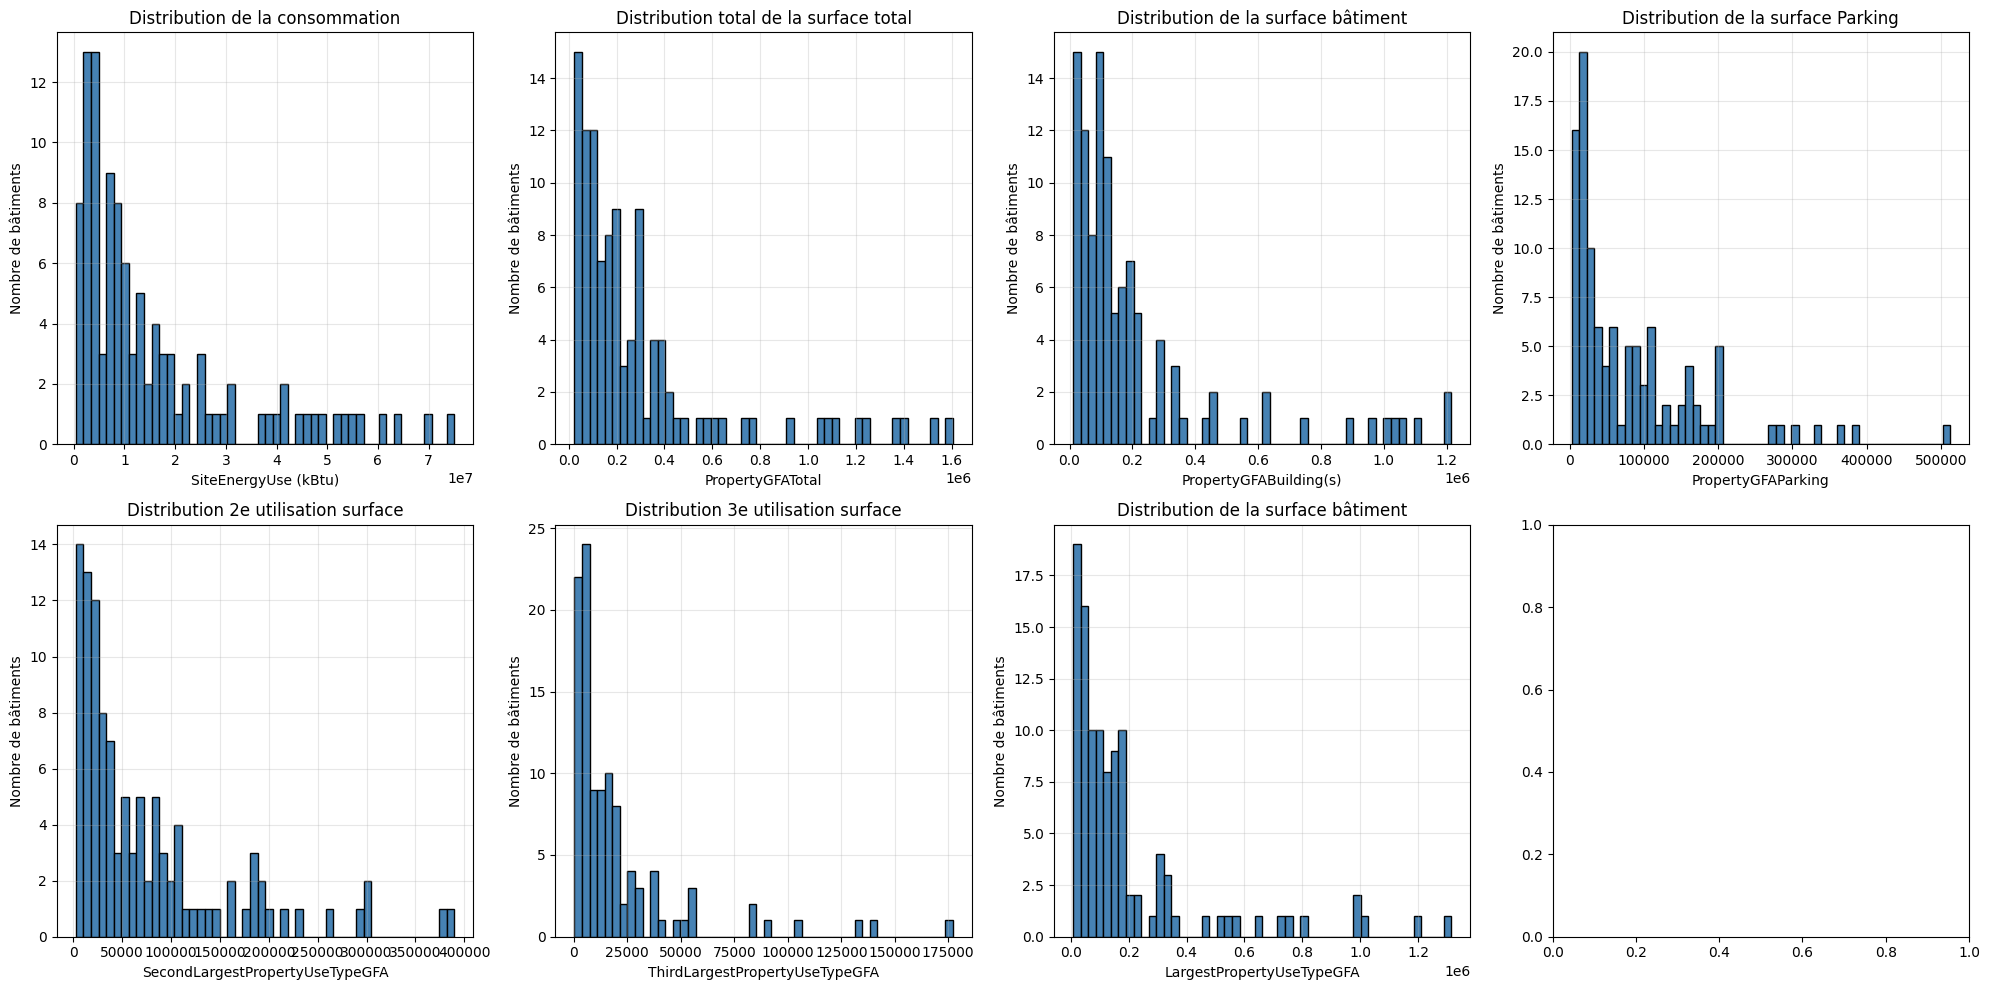

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

df_no_zero = df_clean[
    (df_clean['SiteEnergyUse(kBtu)'] > 0) &
    (df_clean['PropertyGFATotal'] > 0) &
    (df_clean['PropertyGFABuilding(s)'] > 0)&
    (df_clean['PropertyGFAParking'] > 0)&
    (df_clean['LargestPropertyUseTypeGFA'] > 0)&
    (df_clean['SecondLargestPropertyUseTypeGFA'] > 0)&
    (df_clean['ThirdLargestPropertyUseTypeGFA'] > 0)
    ]

# Graphique 1 : Histogramme SiteEnergyUse(kBtu)
axes[0,0].hist(df_no_zero['SiteEnergyUse(kBtu)'], bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_xlabel('SiteEnergyUse (kBtu)')
axes[0,0].set_ylabel('Nombre de bâtiments')
axes[0,0].set_title('Distribution de la consommation')
axes[0,0].grid(True, alpha=0.3)

# Graphique 2 : Histogramme PropertyGFATotal
axes[0, 1].hist(df_no_zero['PropertyGFATotal'], bins=50, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('PropertyGFATotal')
axes[0, 1].set_ylabel('Nombre de bâtiments')
axes[0, 1].set_title('Distribution total de la surface total')
axes[0, 1].grid(True, alpha=0.3)

# Graphique 3 : Histogramme PropertyGFABuilding(s)
axes[0, 2].hist(df_no_zero['PropertyGFABuilding(s)' ], bins=50, color='steelblue', edgecolor='black')
axes[0, 2].set_xlabel('PropertyGFABuilding(s)')
axes[0, 2].set_ylabel('Nombre de bâtiments')
axes[0, 2].set_title('Distribution de la surface bâtiment')
axes[0, 2].grid(True, alpha=0.3)

# Graphique 4 : Histogramme PropertyGFAParking
axes[0,3].hist(df_no_zero['PropertyGFAParking'], bins=50, color='steelblue', edgecolor='black')
axes[0,3].set_xlabel('PropertyGFAParking')
axes[0,3].set_ylabel('Nombre de bâtiments')
axes[0,3].set_title('Distribution de la surface Parking')
axes[0,3].grid(True, alpha=0.3)


# Graphique 1 : Distribution 'SecondLargestPropertyUseTypeGFA'
axes[1, 0].hist(df_no_zero['SecondLargestPropertyUseTypeGFA'], bins=50, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('SecondLargestPropertyUseTypeGFA')
axes[1, 0].set_ylabel('Nombre de bâtiments')
axes[1, 0].set_title('Distribution 2e utilisation surface')
axes[1, 0].grid(True, alpha=0.3)

# Graphique 2 : Distribution 'ThirdLargestPropertyUseTypeGFA'
axes[1, 1].hist(df_no_zero['ThirdLargestPropertyUseTypeGFA'], bins=50, color='steelblue', edgecolor='black')
axes[1, 1].set_xlabel('ThirdLargestPropertyUseTypeGFA')
axes[1, 1].set_ylabel('Nombre de bâtiments')
axes[1, 1].set_title('Distribution 3e utilisation surface')
axes[1, 1].grid(True, alpha=0.3)
    
    # Graphique 3 : Histogramme LargestPropertyUseTypeGFA
axes[1, 2].hist(df_no_zero['LargestPropertyUseTypeGFA'], bins=50, color='steelblue', edgecolor='black')
axes[1, 2].set_xlabel('LargestPropertyUseTypeGFA')
axes[1, 2].set_ylabel('Nombre de bâtiments')
axes[1, 2].set_title('Distribution de la surface bâtiment')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


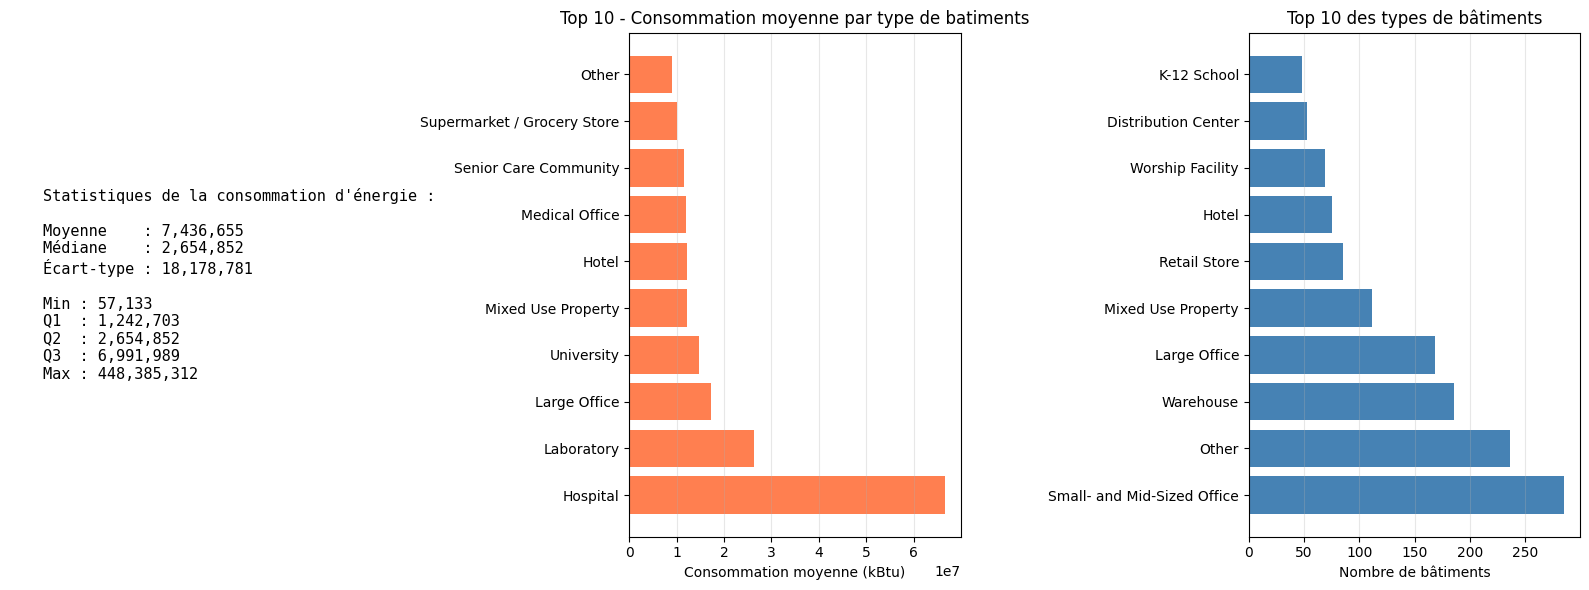

In [24]:
# Graphique 3 : Statistiques
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
stats_text = f"""
Statistiques de la consommation d'énergie :

Moyenne    : {df_clean['SiteEnergyUse(kBtu)'].mean():,.0f}
Médiane    : {df_clean['SiteEnergyUse(kBtu)'].median():,.0f}
Écart-type : {df_clean['SiteEnergyUse(kBtu)'].std():,.0f}

Min : {df_clean['SiteEnergyUse(kBtu)'].min():,.0f}
Q1  : {df_clean['SiteEnergyUse(kBtu)'].quantile(0.25):,.0f}
Q2  : {df_clean['SiteEnergyUse(kBtu)'].quantile(0.50):,.0f}
Q3  : {df_clean['SiteEnergyUse(kBtu)'].quantile(0.75):,.0f}
Max : {df_clean['SiteEnergyUse(kBtu)'].max():,.0f}
"""
axes[0].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center')
axes[0].axis('off')

# Graphique 2 : Consommation moyenne par type
mean_consumption = df_clean.groupby('PrimaryPropertyType')['SiteEnergyUse(kBtu)'].mean().sort_values(ascending=False).head(10)
axes[1].barh(range(len(mean_consumption)), mean_consumption.values, color='coral')
axes[1].set_yticks(range(len(mean_consumption)))
axes[1].set_yticklabels(mean_consumption.index)
axes[1].set_xlabel('Consommation moyenne (kBtu)')
axes[1].set_title('Top 10 - Consommation moyenne par type de batiments')
axes[1].grid(axis='x', alpha=0.3)

# Graphique 1 : Nombre de bâtiments par type
type_counts = df_clean['PrimaryPropertyType'].value_counts().head(10)
axes[2].barh(range(len(type_counts)), type_counts.values, color='steelblue')
axes[2].set_yticks(range(len(type_counts)))
axes[2].set_yticklabels(type_counts.index)
axes[2].set_xlabel('Nombre de bâtiments')
axes[2].set_title('Top 10 des types de bâtiments')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Analyse**  

**Consommation d'énergie par rapport au nombre de batiments.**  
Pour une meilleur visualisation, un histogramme en echelle log a été fait, et les batiments de production 0 (il y en a 16) ont été exclus.  
-> **la consommation d'energie n'est pas lié au nombre de batiments** car l'histograme s'écrase. 

**Graphique Top 10 des types de batiments.**  
Bâtiments les plus nombreux sont Small and Mid Sized OPffice / petit et moyen bureau, Other / autres, WareHouse/ entrepot.

**Graphique Top 10 - Consommation moyenne par type de batiments**  
grand consommateur d'energie (consommation doublé) : Hospital -> les hopitaux, puis Laboratory -> les laboratoires, Large Office -> Bureaux et de façon à peu près similaire : University -> Université, Mixed Use Property -> Propriété mixes, Hotel.  
Cela confirme que **La consommation d'energie n'est pas lié au nombre de batiment**

#### b) Partie 2 : Analyse approfondie Surface vs Consommationde la variable cible : SiteEnergyUse(kBtu)
  - Analyse avec la **date de construction** des batiments
  - Analyse avec la **surface** des batiments

### E/ Évaluation de deux approches : IQR et Z-SCORE de la Target *SiteEnergyUse*

In [25]:
# ===== MÉTHODE 1 : IQR =====
print("\n1️⃣ MÉTHODE IQR (Interquartile Range)")
print("-"*80)

Q1 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_basse_iqr = Q1 - 1.5 * IQR
limite_haute_iqr = Q3 + 1.5 * IQR

outliers_iqr = df_clean[(df_clean['SiteEnergyUse(kBtu)'] < limite_basse_iqr) | 
                         (df_clean['SiteEnergyUse(kBtu)'] > limite_haute_iqr)]

print(f"   Limite basse : {limite_basse_iqr:,.0f}")
print(f"   Limite haute : {limite_haute_iqr:,.0f}")
print(f"   IQR : {IQR:,.0f}")
print(f"   Nombre d'outliers détectés : {len(outliers_iqr)} ({len(outliers_iqr)/len(df_clean)*100:.1f}%)")

# ===== MÉTHODE 2 : Z-SCORE =====
print("\n2️⃣ MÉTHODE Z-SCORE (écart à la moyenne)")
print("-"*80)

mean = df_clean['SiteEnergyUse(kBtu)'].mean()
std = df_clean['SiteEnergyUse(kBtu)'].std()

# Calculer le z-score pour chaque valeur
df_clean['z_score'] = np.abs((df_clean['SiteEnergyUse(kBtu)'] - mean) / std)

# Seuil classique : |z| > 3
outliers_zscore = df_clean[df_clean['z_score'] > 3]

print(f"   Moyenne : {mean:,.0f}")
print(f"   Écart-type : {std:,.0f}")
print(f"   Seuil utilisé : |z-score| > 3")
print(f"   Nombre d'outliers détectés : {len(outliers_zscore)} ({len(outliers_zscore)/len(df_clean)*100:.1f}%)")

# ===== COMPARAISON =====
print("\n📊 COMPARAISON")
print("-"*80)
print(f"   IQR détecte : {len(outliers_iqr)} outliers")
print(f"   Z-score détecte : {len(outliers_zscore)} outliers")

# Combien sont communs aux deux méthodes ?
communs = set(outliers_iqr.index).intersection(set(outliers_zscore.index))
print(f"   Outliers communs aux deux méthodes : {len(communs)}")

print("\n" + "="*80)

# Nettoyer la colonne temporaire
df_clean = df_clean.drop(columns=['z_score'])


1️⃣ MÉTHODE IQR (Interquartile Range)
--------------------------------------------------------------------------------
   Limite basse : -7,381,228
   Limite haute : 15,615,920
   IQR : 5,749,287
   Nombre d'outliers détectés : 169 (11.1%)

2️⃣ MÉTHODE Z-SCORE (écart à la moyenne)
--------------------------------------------------------------------------------
   Moyenne : 7,436,655
   Écart-type : 18,178,781
   Seuil utilisé : |z-score| > 3
   Nombre d'outliers détectés : 16 (1.1%)

📊 COMPARAISON
--------------------------------------------------------------------------------
   IQR détecte : 169 outliers
   Z-score détecte : 16 outliers
   Outliers communs aux deux méthodes : 16



***Analyse***  

Selon le calcul des deux métriques Outlier.   
Nous avons une différence de 156 Outliers (IQR 174 contre Z-score 18).   
Le calcul de **Z-score** est basé sur la moyenne des variables, il prend donc on compte tous les Outliers (dont les valeurs les + extreme) ce qui biaise la 'normalité' du score..  

**IQR*** prend une dispersion entre 25% et 75% des valeurs. Cela donne une vision 'nomale' des données. 

On voit que la dispersion des valeurs Ecart-type et IQR sont très différentes dans leur valeurs **Écart-type : 17 654 702** et **IQR : 5,538,065**

*Pour une étude plus rigoureuse, je prend comme reference d'Outlier IQR.*

📊 VISUALISATION DE LA VARIABLE CIBLE : SiteEnergyUse(kBtu)
--------------------------------------------------------------------------------


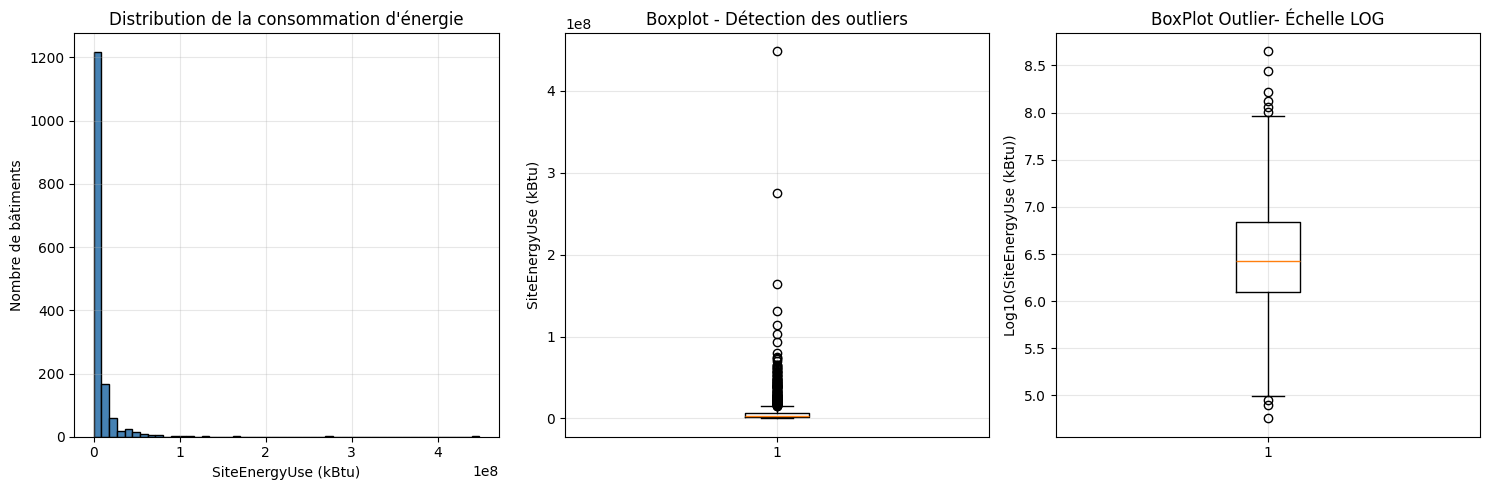

In [26]:
print("📊 VISUALISATION DE LA VARIABLE CIBLE : SiteEnergyUse(kBtu)")
print("-"*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# histogramme
axes[0].hist(df_clean['SiteEnergyUse(kBtu)'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('SiteEnergyUse (kBtu)')
axes[0].set_ylabel('Nombre de bâtiments')
axes[0].set_title('Distribution de la consommation d\'énergie')
axes[0].grid(True, alpha=0.3)

# Boxplot - Outliers
axes[1].boxplot(df_clean['SiteEnergyUse(kBtu)'].dropna())
axes[1].set_ylabel('SiteEnergyUse (kBtu)')
axes[1].set_title('Boxplot - Détection des outliers')
axes[1].grid(True, alpha=0.3)

# Boxplot - Outlier Distribution LOG 
axes[2].boxplot(np.log10(df_clean['SiteEnergyUse(kBtu)'].dropna() + 1))
axes[2].set_ylabel('Log10(SiteEnergyUse (kBtu))')
axes[2].set_title('BoxPlot Outlier- Échelle LOG')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


On analyse quel type de batiments constituent les Outliers, et voir s'il y a des incohérences entre les  batiments et la production excessive.

Ainsi on  va comparer *SiteEnergyUse* avec :
- le type de batiments
- la surface des batiments

### F/ Observation des Outliers de la target

In [27]:
Q1 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_basse = Q1 - 1.5 * IQR
limite_haute = Q3 + 1.5 * IQR
outliers = df_clean[df_clean['SiteEnergyUse(kBtu)'] > limite_haute]

print(f"\n📊 Types de bâtiments parmi les outliers :")
print(outliers['PrimaryPropertyType'].value_counts())

print(f"\n📊 Description de la surface des bâtiments parmi les outliers :")
print(outliers['PropertyGFATotal'].describe())

print(f"\n📊 Top 5 des plus gros consommateurs parmi les outliers:")
top5 = outliers.nlargest(5, 'SiteEnergyUse(kBtu)')[['BuildingType','PrimaryPropertyType','PropertyGFATotal','SiteEnergyUse(kBtu)']]
print(top5)

print("\n" + "="*80)


📊 Types de bâtiments parmi les outliers :
PrimaryPropertyType
Large Office                   66
Other                          29
Mixed Use Property             16
Hotel                          15
Medical Office                 12
Retail Store                    6
Laboratory                      6
Senior Care Community           5
University                      4
Hospital                        3
Small- and Mid-Sized Office     2
Warehouse                       1
Distribution Center             1
Refrigerated Warehouse          1
Supermarket / Grocery Store     1
Residence Hall                  1
Name: count, dtype: int64

📊 Description de la surface des bâtiments parmi les outliers :
count    1.690000e+02
mean     4.566321e+05
std      3.886293e+05
min      3.397100e+04
25%      1.900000e+05
50%      3.363300e+05
75%      5.403600e+05
max      2.200000e+06
Name: PropertyGFATotal, dtype: float64

📊 Top 5 des plus gros consommateurs parmi les outliers:
        BuildingType PrimaryPro

**Analyse**  
Les Outliers de la Target sont légitimes.  
On peut se poser la question si **Mixed Use Property, Other, Hospital, University** peuvent être considéré comme des lieux d'habitation ?

Ces bâtiments consomment beaucoup d'énergie :
- Universités éclairage, materiel informatique.
- Hôpitaux 24h/24 avec équipements médicaux
- Bâtiment à usage mixed
- Autres

On regarde plus en détails ce que contient les 29 **Other**

#### a) Analyse des individus "Other" dans Outlier de la target

In [28]:
Q1 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_haute = Q3 + 1.5 * IQR

outliers = df_clean[df_clean['SiteEnergyUse(kBtu)'] > limite_haute]

# Filtrer les "Other" dans 'PrimaryPropertyType'/ il y en a 29
other_outliers = outliers[outliers['PrimaryPropertyType'] == 'Other']

# Usage principal réel
print("\n 1/ Usage principal (LargestPropertyUseType) :")
print(other_outliers['LargestPropertyUseType'].value_counts())

# Top 5 les + energivores
print("--------"*10)
print("\n 3/ Top 10 les plus énergivores :")
display(other_outliers.nlargest(10, 'SiteEnergyUse(kBtu)')[
    ['BuildingType','ListOfAllPropertyUseTypes','LargestPropertyUseType', 'PropertyGFABuilding(s)', 'SiteEnergyUse(kBtu)','NumberofBuildings' ]
])

print("--------"*10)


 1/ Usage principal (LargestPropertyUseType) :
LargestPropertyUseType
Other                                    13
Other - Entertainment/Public Assembly     3
Data Center                               3
Urgent Care/Clinic/Other Outpatient       2
Other - Recreation                        2
Library                                   1
Courthouse                                1
Parking                                   1
Strip Mall                                1
Other - Mall                              1
Lifestyle Center                          1
Name: count, dtype: int64
--------------------------------------------------------------------------------

 3/ Top 10 les plus énergivores :


,BuildingType,ListOfAllPropertyUseTypes,LargestPropertyUseType,PropertyGFABuilding(s),SiteEnergyUse(kBtu),NumberofBuildings
558,NonResidential,"Data Center, Office",Data Center,429405,274682208.0,1.0
340,Campus,"Other, Parking",Other,535947,131373880.0,1.0
119,NonResidential,Other,Other,230638,65336980.0,1.0
187,NonResidential,Other,Other,230880,62197176.0,1.0
329,NonResidential,Urgent Care/Clinic/Other Outpatient,Urgent Care/Clinic/Other Outpatient,158738,61762380.0,1.0
155,NonResidential,"Other - Entertainment/Public Assembly, Parking",Other - Entertainment/Public Assembly,1258280,59757440.0,1.0
158,NonResidential,Other - Entertainment/Public Assembly,Other - Entertainment/Public Assembly,1172127,58761304.0,1.0
21,NonResidential,Other,Other,385274,47859812.0,1.0
564,NonResidential,"Office, Other - Entertainment/Public Assembly,...",Other - Mall,947987,46510960.0,1.0
20,NonResidential,Courthouse,Courthouse,540360,44984468.0,1.0


--------------------------------------------------------------------------------


**ANALYSE**  
On remarque deux individus très énergivores : 
- 1 Data Center, sa consommation par rapport à la superficie et son nombre de batiment est extreme. 
- 1 campus/Parking, sa consommation d'energie par rapport à sa superficie et nombre de batiment est cohérent.

In [29]:
print(f"Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )

Le nouveau dataset est composé de 1522 lignes et de 35 colonnes


**Maintenant, que mon dataset possède des valeurs exploitable, je vais regarder mes features incomplètes**

## 5 / Visualisation des features incomplètes

/tmp/ipykernel_9683/1784392954.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/veron/miniconda3/envs/seattle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


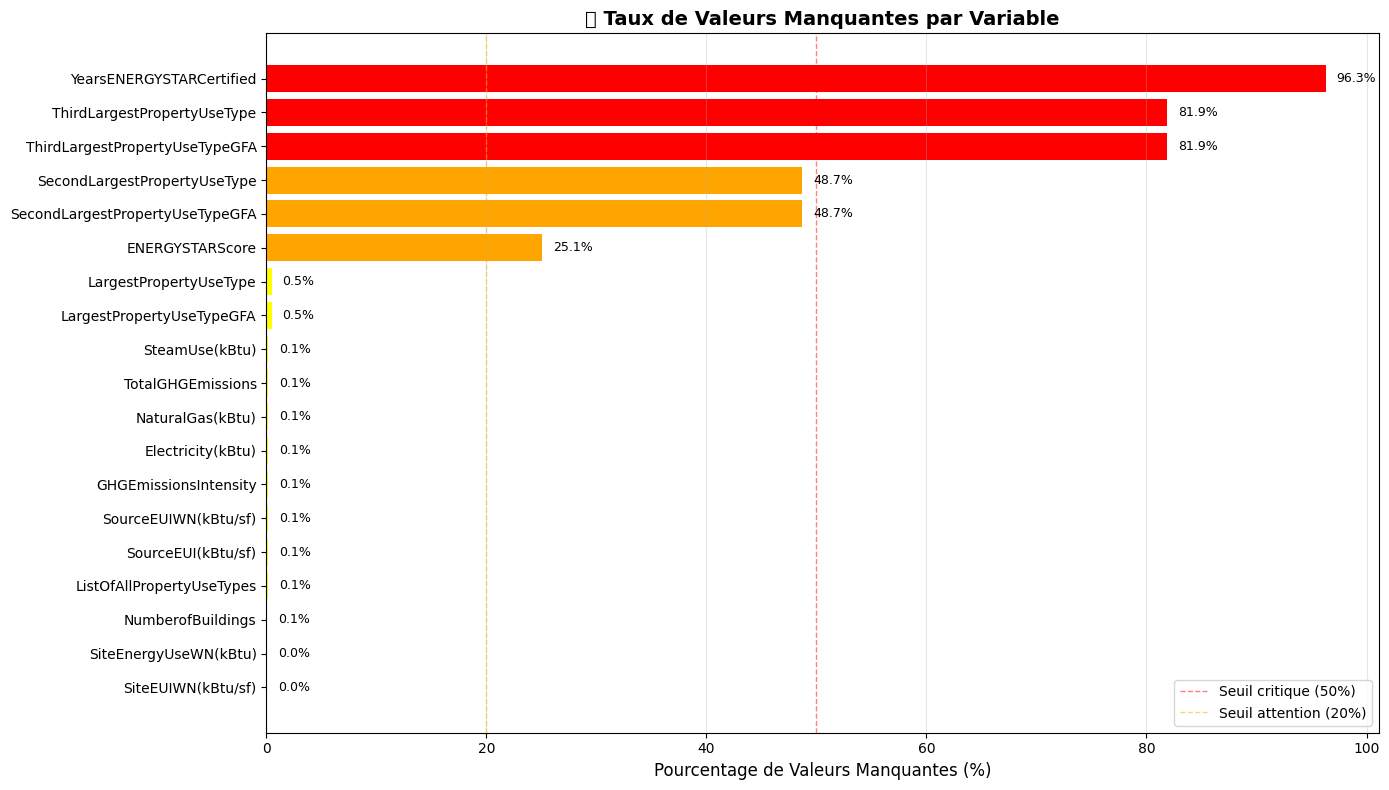

In [30]:
missing = pd.DataFrame({
    'Colonne': df.columns,
    'NaN_Count': df.isnull().sum(),
    'NaN_Percent': (df.isnull().sum() / len(df) * 100).round(2),
    'Type': df.dtypes
})

missing = missing[missing['NaN_Count'] > 0].sort_values('NaN_Percent', ascending=False)
fig, ax = plt.subplots(figsize=(14, 8))

if len(missing) > 0:
    missing_sorted = missing.sort_values('NaN_Percent', ascending=True)
    colors = ['red' if x > 50 else 'orange' if x > 20 else 'yellow' 
              for x in missing_sorted['NaN_Percent']]
    
    bars = ax.barh(missing_sorted['Colonne'], missing_sorted['NaN_Percent'], color=colors)
    ax.set_xlabel('Pourcentage de Valeurs Manquantes (%)', fontsize=12)
    ax.set_title('📊 Taux de Valeurs Manquantes par Variable', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Seuil critique (50%)')
    ax.axvline(x=20, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Seuil attention (20%)')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Aucune valeur manquante dans le dataset !")

**Analyse par catégories des valeurs manquantes**
- YearsENERGYSTARCertified (94%)
- ThirdLargestPropertyUseType (78%)
- ThirdLargestPropertyUseTypeGFA (78%)
- SecondLargestPropertyUseType (48%)
- SecondLargestPropertyUseTypeGFA (48%)
- ENERGYSTARScore (34%)

In [31]:
df_clean = df_clean.drop(columns=['YearsENERGYSTARCertified'])
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   BuildingType                     1522 non-null   object 
 2   PrimaryPropertyType              1522 non-null   object 
 3   CouncilDistrictCode              1522 non-null   int64  
 4   Neighborhood                     1522 non-null   object 
 5   Latitude                         1522 non-null   float64
 6   Longitude                        1522 non-null   float64
 7   YearBuilt                        1522 non-null   int64  
 8   NumberofBuildings                1522 non-null   float64
 9   NumberofFloors                   1522 non-null   int64  
 10  PropertyGFATotal                 1522 non-null   int64  
 11  PropertyGFAParking               1522 non-null   int64  
 12  PropertyGFABuilding(s)   


4️⃣ Année de construction vs Consommation
--------------------------------------------------------------------------------


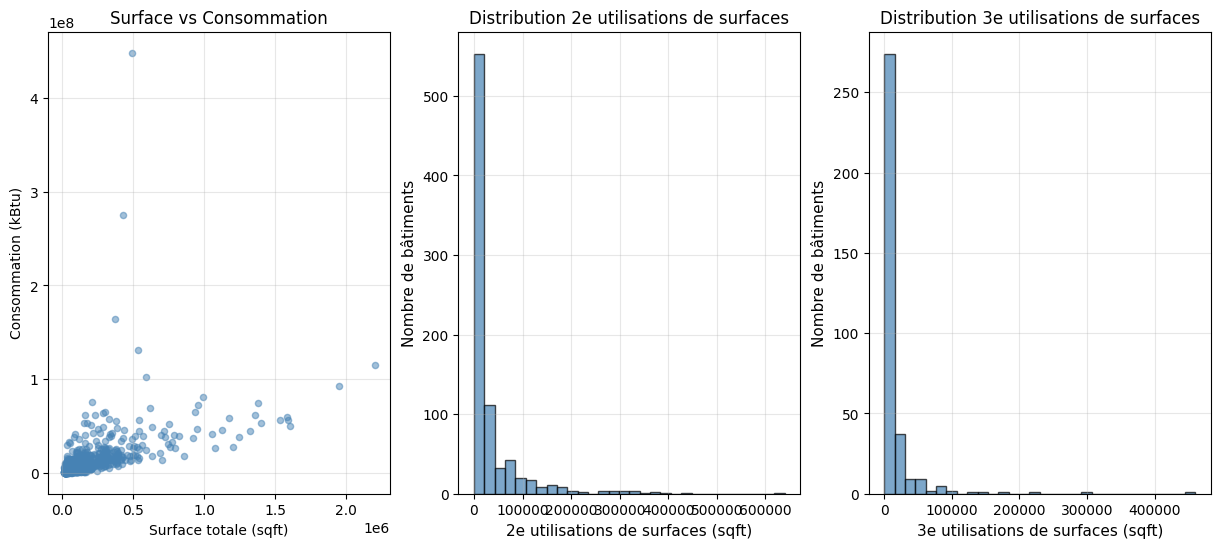

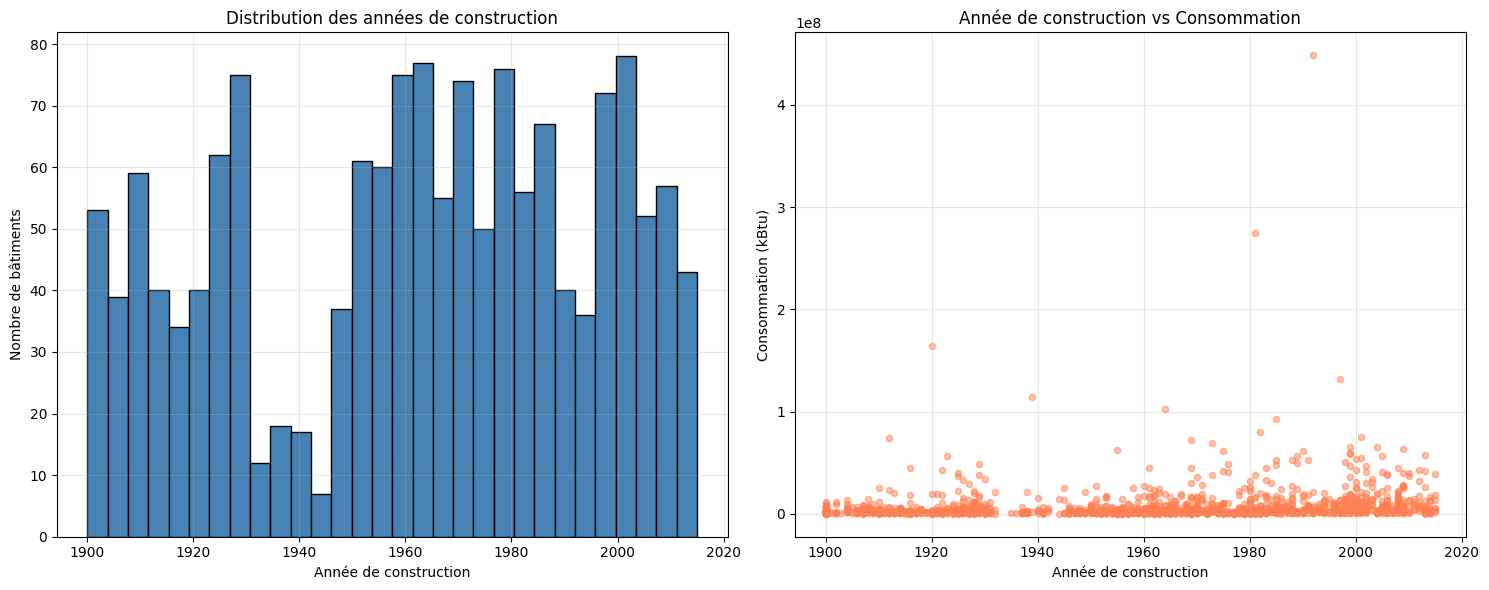

   Corrélation Année/Consommation : 0.149
   Corrélation Surface Totale/Consommation : 0.553


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Graphique 1 : Scatter plot
axes[0].scatter(df_clean['PropertyGFATotal'], 
                df_clean['SiteEnergyUse(kBtu)'], 
                alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel('Surface totale (sqft)')
axes[0].set_ylabel('Consommation (kBtu)')
axes[0].set_title('Surface vs Consommation')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_clean['SecondLargestPropertyUseTypeGFA'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('2e utilisations de surfaces (sqft)', fontsize=11)
axes[1].set_ylabel('Nombre de bâtiments', fontsize=11)
axes[1].set_title('Distribution 2e utilisations de surfaces', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].hist(df_clean['ThirdLargestPropertyUseTypeGFA'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('3e utilisations de surfaces (sqft)', fontsize=11)
axes[2].set_ylabel('Nombre de bâtiments', fontsize=11)
axes[2].set_title('Distribution 3e utilisations de surfaces', fontsize=12)
axes[2].grid(True, alpha=0.3)



# ============================================================================
# 4. ANNÉE DE CONSTRUCTION vs Consommation
# ============================================================================
print("\n4️⃣ Année de construction vs Consommation")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1 : Distribution des années
axes[0].hist(df_clean['YearBuilt'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Année de construction')
axes[0].set_ylabel('Nombre de bâtiments')
axes[0].set_title('Distribution des années de construction')
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Année vs Consommation
axes[1].scatter(df_clean['YearBuilt'], 
                df_clean['SiteEnergyUse(kBtu)'], 
                alpha=0.5, s=20, color='coral')
axes[1].set_xlabel('Année de construction')
axes[1].set_ylabel('Consommation (kBtu)')
axes[1].set_title('Année de construction vs Consommation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculer la corrélation
correlation = df_clean['PropertyGFATotal'].corr(df_clean['SiteEnergyUse(kBtu)'])
correlation_year = df_clean['YearBuilt'].corr(df_clean['SiteEnergyUse(kBtu)'])

print(f"   Corrélation Année/Consommation : {correlation_year:.3f}")
print(f"   Corrélation Surface Totale/Consommation : {correlation:.3f}")

## Conclusion : Enregistrement du nouveau Dataset

In [33]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   BuildingType                     1522 non-null   object 
 2   PrimaryPropertyType              1522 non-null   object 
 3   CouncilDistrictCode              1522 non-null   int64  
 4   Neighborhood                     1522 non-null   object 
 5   Latitude                         1522 non-null   float64
 6   Longitude                        1522 non-null   float64
 7   YearBuilt                        1522 non-null   int64  
 8   NumberofBuildings                1522 non-null   float64
 9   NumberofFloors                   1522 non-null   int64  
 10  PropertyGFATotal                 1522 non-null   int64  
 11  PropertyGFAParking               1522 non-null   int64  
 12  PropertyGFABuilding(s)   

In [34]:
df_clean.to_pickle('df_clean.pkl')
print("✅ Fichier sauvegardé en pickle")
print(f"\n📊 RÉCAPITULATIF :")
print(f"  Dataset initial : {len(df):,} lignes × {len(df.columns)} colonnes")
print(f"  Dataset final : {len(df_clean):,} lignes × {len(df_clean.columns)} colonnes")
print(f"  NaN restants : {df_clean.isnull().sum().sum()}")

✅ Fichier sauvegardé en pickle

📊 RÉCAPITULATIF :
  Dataset initial : 3,170 lignes × 35 colonnes
  Dataset final : 1,522 lignes × 34 colonnes
  NaN restants : 4281


**Analyse**  

1/ Analyse des Variables

- Variable TotalGHGEmissions : 
    - La valeur minimale est de  -0.800000, on ne peut pas avoir une émission de CO2 négative -> nous avons une valeur aberrante. 
    - La médiane est de 49.44 (2nd quartile) et l a valeur max est de 16 870 -> cette amplitude nous suggère un outlier.  


- Variable SiteEnergyUse(kBtu):
    - Valeur min: 0 kBtu. Certains batiments ne consomment pas d'énergie, cela concerne 16 bâtiments.
    - Valeur max : 4.48x10⁸ est bien supérieur à la médiane (7.13x10⁶)-> variable qui a des extremes. minimum et maximum, mais nous avons vu dans le traitement des Outliers qu'il y a des consommations différentes selon le type et la surface des batiments.

**Pour Target je vais prendre SiteEnergyUse(kBtu)**

2/ Etudes des corrélations

Il y a une corrélation entre la surface et la consommation.  
Il n'y a pas très peu de corrélation entre l'année de constructions et la consommations.  
Il n'y a pas de corrélation entre la consommation d'energie et le nombre de batiments.  


3/ Consommation moyenne par type de batiments
grand consommateur d'energie (consommation doublé) :
   - 1/ Hospital -> les hopitaux
 
puis
 - 2/ Laboratory -> les laboratoires

puis 
 - 3/ Large Office -> Bureaux
 
et de façon à peu près similaire :
 - 4/ University -> Université
 - 5/ Mixed Use Property -> Propriété mixes
 - 6/ Hotel
 
**Étape suivante**

La suite de l’analyse portera sur la détection du data leakage, à travers :

l’étude des corrélations entre variables à l’aide d’une matrice de corrélation ;

la mise en place et la comparaison de plusieurs modèles :

- modèle dummy (baseline),

- régression linéaire,

- Random Forest,

- SVR.
